In [1]:
!pip install pypsa

In [2]:
import pypsa

C:\Users\User\AppData\Local\Temp\ipykernel_32052\4200437341.py:21: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize()
Index(['A', 'B'], dtype='str', name='name')
Index(['Line AB'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.04s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 3 primals, 8 duals
Objective: 1.20e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Line-fix-s-lower, Line-fix-s-upper were not assigned to the network.


Газ: 30.0 МВт
Солнце: 60.0 МВт
Поток A→B: 30.0 МВт


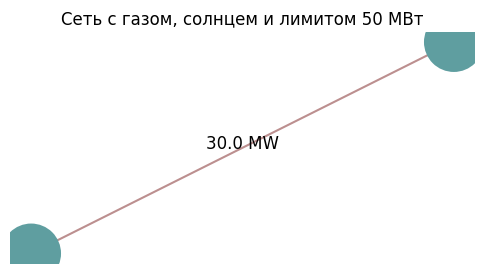

In [7]:
import pypsa
import matplotlib.pyplot as plt

network = pypsa.Network()

# Шины
network.add("Bus", "A", v_nom=10, x=0, y=0)
network.add("Bus", "B", v_nom=10, x=2, y=1)

# Генераторы
network.add("Generator", "Gas", bus="A", p_nom=100, marginal_cost=40)
network.add("Generator", "Sun", bus="B", p_nom=60, marginal_cost=0)

# Нагрузка
network.add("Load", "City", bus="B", p_set=90)

# Линия (имя "Line AB")
network.add("Line", "Line AB", bus0="A", bus1="B", x=0.1, r=0.02, s_nom=50)

network.set_snapshots([0])
network.optimize()

# Выводим результаты
print("Газ:", network.generators_t.p.loc[0, "Gas"], "МВт")
print("Солнце:", network.generators_t.p.loc[0, "Sun"], "МВт")

# Используем правильное имя линии
line_name = "Line AB"
print("Поток A→B:", network.lines_t.p0.loc[0, line_name], "МВт")

# Визуализация
fig, ax = plt.subplots(figsize=(6,5))
network.plot(ax=ax, title="Сеть с газом, солнцем и лимитом 50 МВт")
flow = network.lines_t.p0.loc[0, line_name]
ax.annotate(f"{flow:.1f} MW", xy=(1, 0.5), xytext=(1, 0.5), fontsize=12, ha='center')
plt.show()

In [6]:
print(network.generators_t.p)
print(network.loads_t.p)           # таблица нагрузки
print(network.lines_t.p0)          # потоки

name      Gas Generator  Sun Panel
snapshot                          
0                  30.0       60.0
name      City
snapshot      
0         90.0
name      Line 1-2
snapshot          
0             30.0


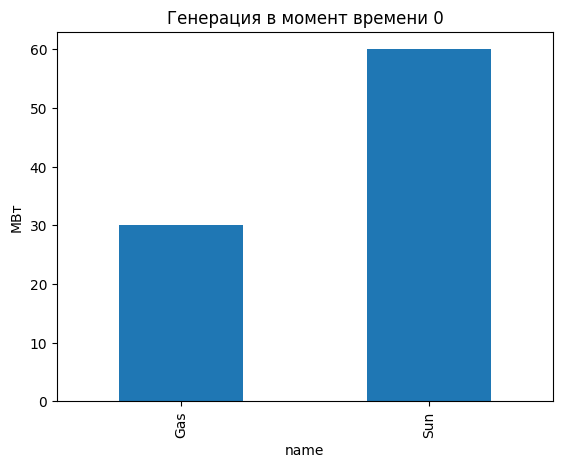

In [8]:
gen_p = network.generators_t.p.loc[0]
gen_p.plot(kind='bar', title='Генерация в момент времени 0')
plt.ylabel('МВт')
plt.show()